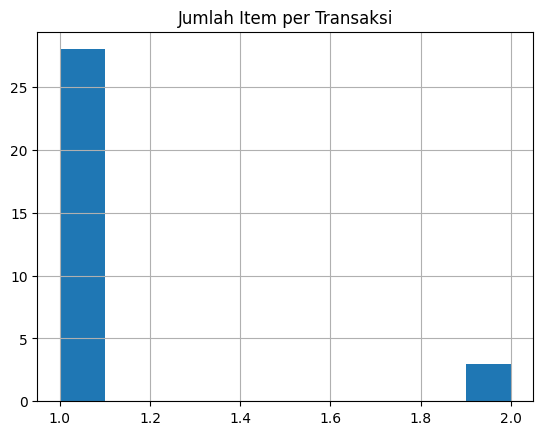

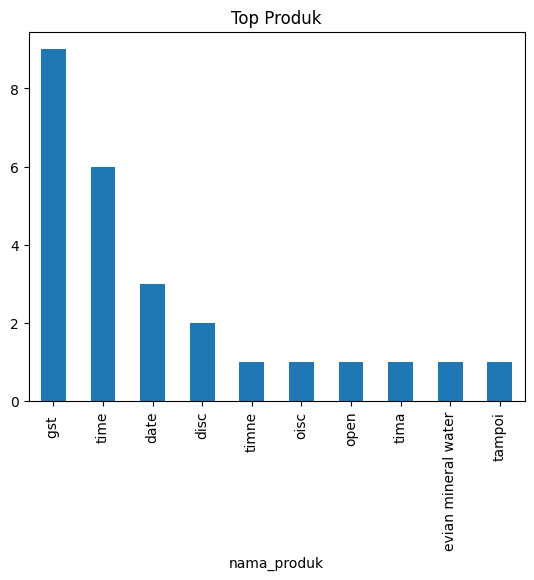

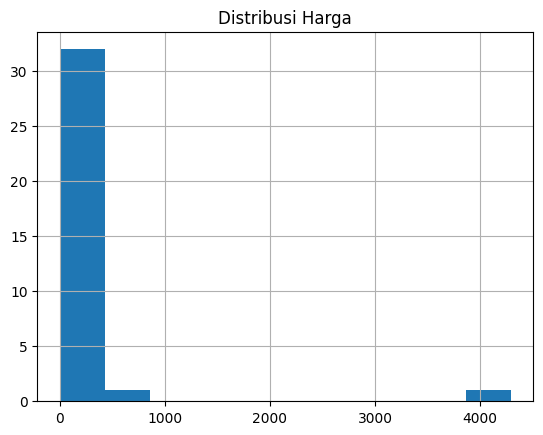

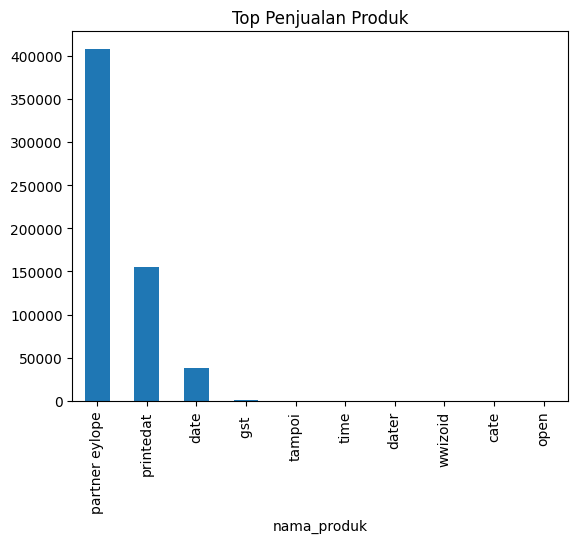

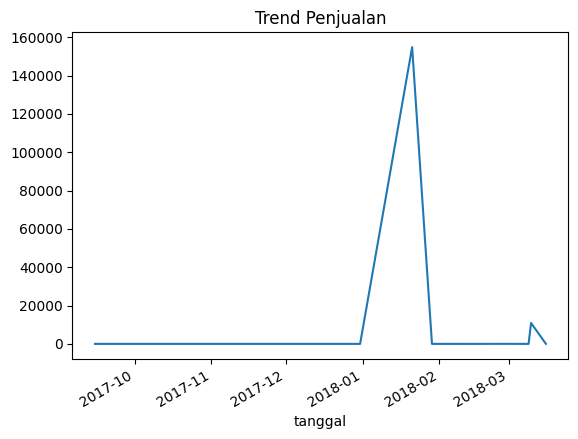

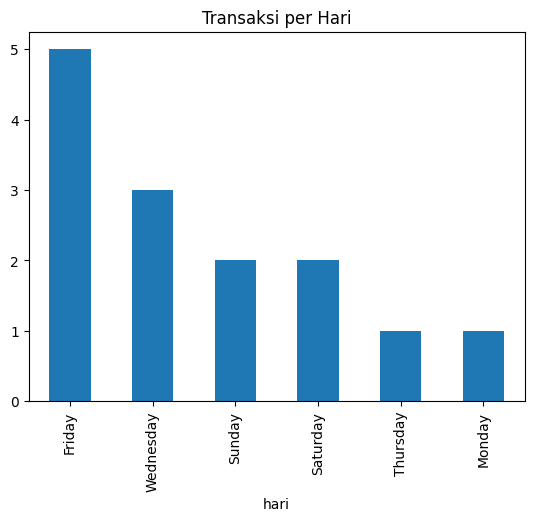

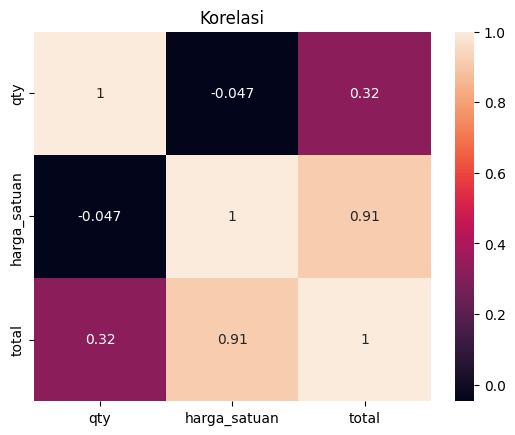

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load data
df = pd.read_csv('/content/drive/MyDrive/capstone/dataset/Dataset ocr 1.multiclass/hasil analisa lanjutt/dataset_clean.csv')

# tipe data
df["tanggal"] = pd.to_datetime(df["tanggal"], errors='coerce')

# buat total jika belum ada
if "total" not in df.columns:
    df["total"] = df["qty"] * df["harga_satuan"]

# ======================
# EDA
# ======================

# 1. jumlah item per transaksi
df.groupby("transaction_id")["nama_produk"].count().hist()
plt.title("Jumlah Item per Transaksi")
plt.show()

# 2. top produk
df["nama_produk"].value_counts().head(10).plot(kind="bar")
plt.title("Top Produk")
plt.show()

# 3. distribusi harga
df["harga_satuan"].hist()
plt.title("Distribusi Harga")
plt.show()

# 4. total penjualan produk
df.groupby("nama_produk")["total"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top Penjualan Produk")
plt.show()

# 5. trend penjualan
df.groupby("tanggal")["total"].sum().plot()
plt.title("Trend Penjualan")
plt.show()

# 6. hari ramai
df["hari"] = df["tanggal"].dt.day_name()
df["hari"].value_counts().plot(kind="bar")
plt.title("Transaksi per Hari")
plt.show()

# 7. korelasi
sns.heatmap(df[["qty","harga_satuan","total"]].corr(), annot=True)
plt.title("Korelasi")
plt.show()

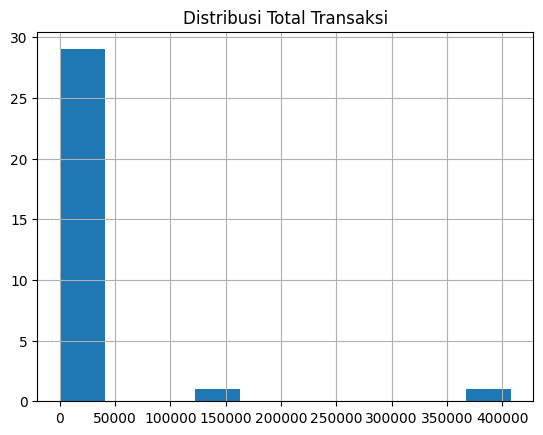

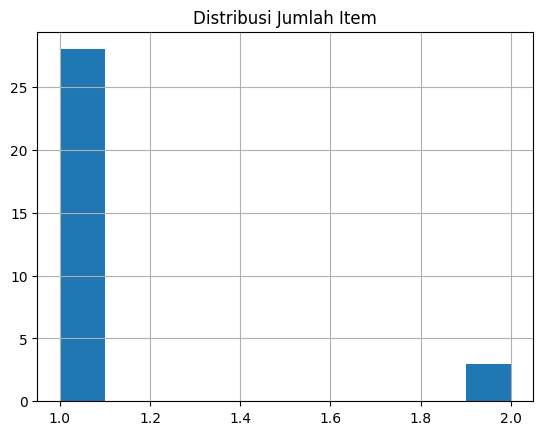

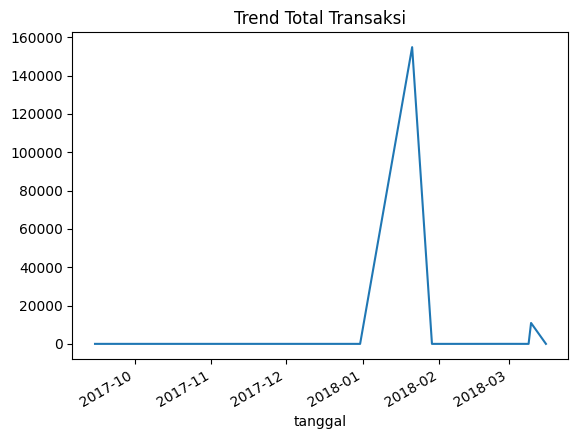

Rata-rata transaksi: 19420.227096774193
      transaction_id    tanggal      total  jumlah_item
21  X51005587267_jpg        NaT  407740.00            1
27  X51005719873_jpg 2018-01-21  154878.28            1
18  X51005442397_jpg        NaT   19009.56            1
7   X51005433552_jpg 2018-03-10   10917.38            1
12  X51005442366_jpg        NaT    8092.48            2


In [3]:
# load data transaksi
df_trx = pd.read_csv('/content/drive/MyDrive/capstone/dataset/Dataset ocr 1.multiclass/hasil analisa lanjutt/dataset_transaksi (1).csv')

df_trx["tanggal"] = pd.to_datetime(df_trx["tanggal"], errors='coerce')

# ======================
# EDA transaksi
# ======================

# 1. distribusi total transaksi
df_trx["total"].hist()
plt.title("Distribusi Total Transaksi")
plt.show()

# 2. jumlah item per transaksi
df_trx["jumlah_item"].hist()
plt.title("Distribusi Jumlah Item")
plt.show()

# 3. trend transaksi harian
df_trx.groupby("tanggal")["total"].sum().plot()
plt.title("Trend Total Transaksi")
plt.show()

# 4. rata-rata belanja
print("Rata-rata transaksi:", df_trx["total"].mean())

# 5. transaksi terbesar
print(df_trx.sort_values(by="total", ascending=False).head())